In [1]:
# Environment setup
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "config").is_dir() and (p / "src").is_dir():
            return p
    raise RuntimeError(f"Could not find project root from {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/mac/Studying/OTTO/scenario_generator


In [2]:
# Load all scenarios
from src.config_loader import ConfigLoader
from src.signal_generator import Scenario, SignalGenerator

loader = ConfigLoader(PROJECT_ROOT / "config")
fault_registry = loader.load_fault_types()
generator = SignalGenerator(loader)

SCENARIOS = [
    "city_drive",
    "highway_cruise",
    "highway_brake_wear_gradual",
]

# Generate each scenario's signals
scenario_data = {}
for name in SCENARIOS:
    path = PROJECT_ROOT / "config" / "scenarios" / f"{name}.yaml"
    scenario = Scenario.from_yaml(path, fault_registry=fault_registry)
    df = generator.generate(scenario)
    scenario_data[name] = {"scenario": scenario, "df": df}
    print(f"  ✓ {name:35s}  shape={df.shape}  duration={scenario.duration_s}s  vehicle={scenario.vehicle_id}")

  ✓ city_drive                           shape=(6000, 11)  duration=60.0s  vehicle=sedan_a
  ✓ highway_cruise                       shape=(9000, 11)  duration=90.0s  vehicle=suv_b
  ✓ highway_brake_wear_gradual           shape=(9000, 11)  duration=90.0s  vehicle=suv_b


In [3]:
#  Enumerate signals
signals = list(generator.signals.keys())

print(f"Total signals: {len(signals)}")
print()
for s in signals:
    spec = generator.signals[s]
    print(f"  {s:30s}  unit={spec['unit']:10s}  range={spec['range']}  resolution={spec['resolution']}")

Total signals: 9

  engine_rpm                      unit=rpm         range=[0, 8000]  resolution=0.25
  throttle_position               unit=percent     range=[0, 100]  resolution=1
  coolant_temperature             unit=celsius     range=[-40, 150]  resolution=1
  brake_pressure                  unit=bar         range=[0, 200]  resolution=0.01
  brake_pedal                     unit=percent     range=[0, 100]  resolution=1
  wheel_speed                     unit=km/h        range=[0, 250]  resolution=0.01
  vehicle_speed                   unit=km/h        range=[0, 250]  resolution=0.01
  longitudinal_acceleration       unit=m/s^2       range=[-10, 5]  resolution=0.01
  crank_position                  unit=degrees     range=[0, 360]  resolution=0.1


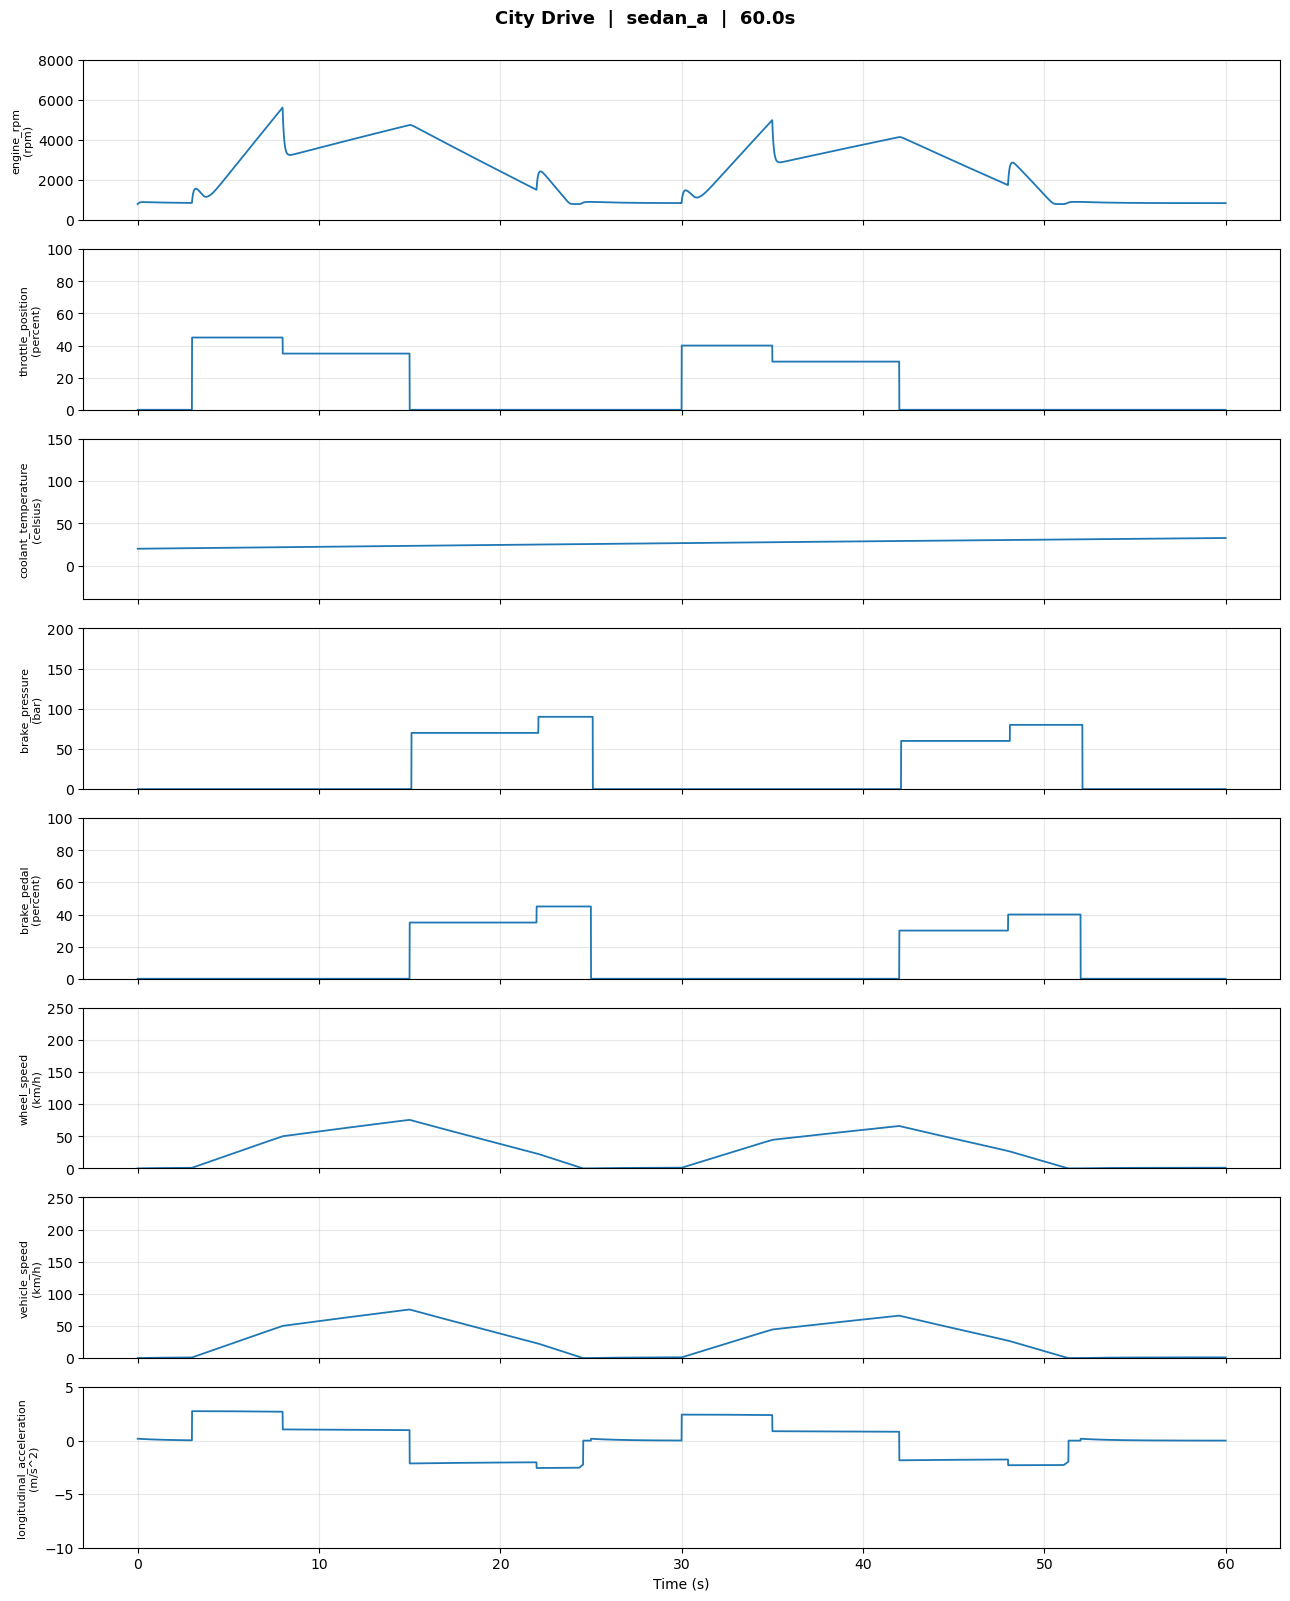

In [ ]:
#  All signals for City Drive
import matplotlib.pyplot as plt

name = "city_drive"
scenario = scenario_data[name]["scenario"]
df = scenario_data[name]["df"]

# Exclude crank_position from full-scenario plots (it aliases at macro scale)
plot_signals = [s for s in signals if s != "crank_position"]



fig, axes = plt.subplots(len(plot_signals), 1,
                         figsize=(13, 2.0 * len(plot_signals)), sharex=True)

for ax, sig in zip(axes, plot_signals):
    spec = generator.signals[sig]
    ax.plot(df["time_s"], df[sig], linewidth=1.3, color="tab:blue")
    ax.set_ylabel(f"{sig}\n({spec['unit']})", fontsize=8)
    ax.set_ylim(spec["range"][0], spec["range"][1])
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"{scenario.name}  |  {scenario.vehicle_id}  |  {scenario.duration_s}s",
    fontsize=13, fontweight="bold", y=0.998,
)
plt.tight_layout()
plt.show()

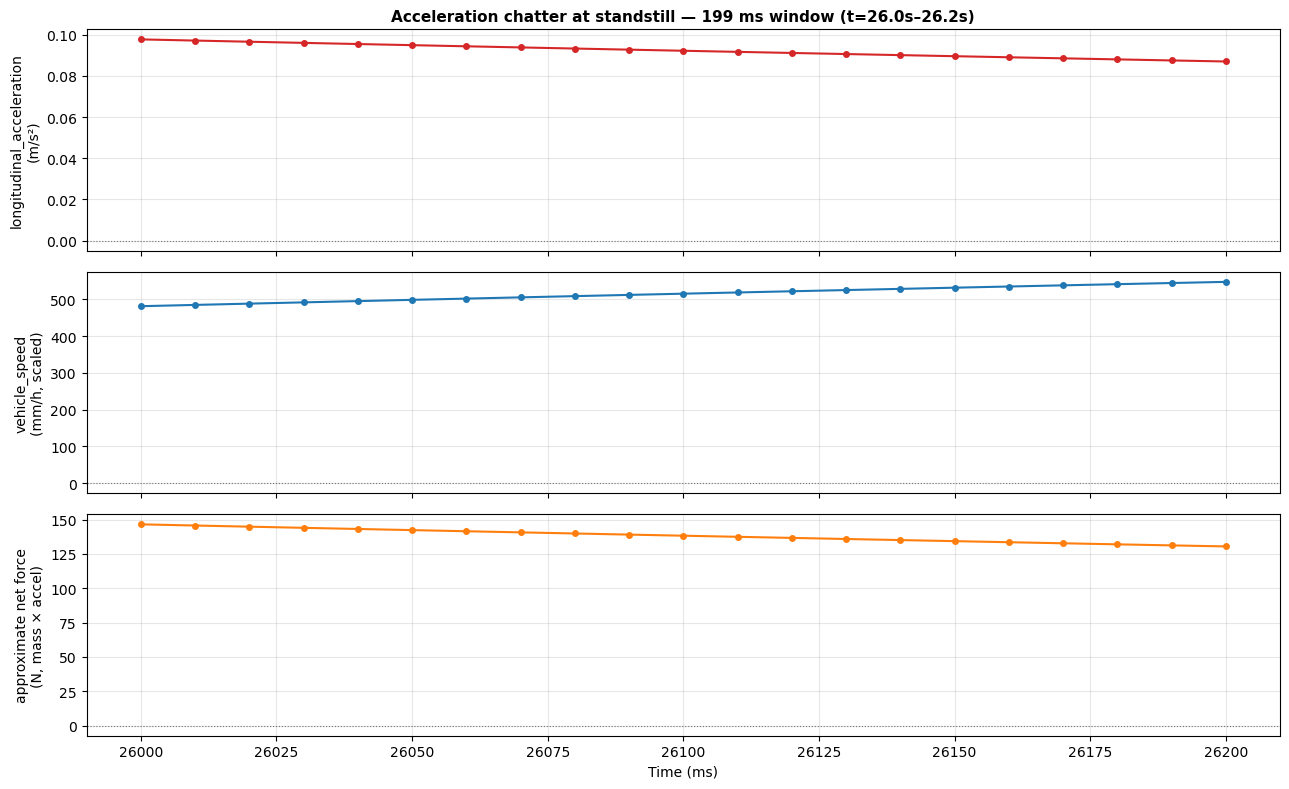

Window: t=26.0s – 26.2s
Samples in window: 21

Acceleration:
  min  = 0.086967 m/s²
  max  = 0.097682 m/s²
  mean = 0.092226 m/s²
  std  = 0.003324 m/s²

Vehicle speed:
  min  = 0.481723 km/h
  max  = 0.547929 km/h

Sign changes in acceleration: 0 over 21 samples
✅ Acceleration is stable (no significant chatter)


In [5]:
# Zoom into acceleration chatter (before vs after fix)
import matplotlib.pyplot as plt
import numpy as np

name = "city_drive"
scenario = scenario_data[name]["scenario"]
df = scenario_data[name]["df"]

# Idle period: t=26–28 s (vehicle stopped, no throttle)
window_start = 26.0
window_end = 26.2   # 200 ms
mask = (df["time_s"] >= window_start) & (df["time_s"] <= window_end)
sub = df[mask]

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

# --- Acceleration (in m/s²) ---
axes[0].plot(sub["time_s"] * 1000, sub["longitudinal_acceleration"],
             linewidth=1.5, color="tab:red", marker="o", markersize=4)
axes[0].axhline(0, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
axes[0].set_ylabel("longitudinal_acceleration\n(m/s²)")
axes[0].grid(alpha=0.3)
axes[0].set_title(
    f"Acceleration chatter at standstill — {int((window_end-window_start)*1000)} ms window "
    f"(t={window_start}s–{window_end}s)",
    fontsize=11, fontweight="bold"
)

# --- Vehicle speed (mm/s scale to see any creep) ---
axes[1].plot(sub["time_s"] * 1000, sub["vehicle_speed"] * 1000,   # km/h → m/h × 1000
             linewidth=1.5, color="tab:blue", marker="o", markersize=4)
axes[1].axhline(0, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
axes[1].set_ylabel("vehicle_speed\n(mm/h, scaled)")
axes[1].grid(alpha=0.3)

# --- Net force (kg·m/s² = N) ---
mass = scenario_data[name]["scenario"].segments and \
       df["longitudinal_acceleration"].values * 1500.0   # approximate mass
axes[2].plot(sub["time_s"] * 1000, sub["longitudinal_acceleration"] * 1500.0,
             linewidth=1.5, color="tab:orange", marker="o", markersize=4)
axes[2].axhline(0, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
axes[2].set_ylabel("approximate net force\n(N, mass × accel)")
axes[2].set_xlabel("Time (ms)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics for the window
print(f"Window: t={window_start}s – {window_end}s")
print(f"Samples in window: {len(sub)}")
print()
print(f"Acceleration:")
print(f"  min  = {sub['longitudinal_acceleration'].min():.6f} m/s²")
print(f"  max  = {sub['longitudinal_acceleration'].max():.6f} m/s²")
print(f"  mean = {sub['longitudinal_acceleration'].mean():.6f} m/s²")
print(f"  std  = {sub['longitudinal_acceleration'].std():.6f} m/s²")
print()
print(f"Vehicle speed:")
print(f"  min  = {sub['vehicle_speed'].min():.6f} km/h")
print(f"  max  = {sub['vehicle_speed'].max():.6f} km/h")
print()
# Detect chatter: count sign flips
accel_vals = sub["longitudinal_acceleration"].values
sign_changes = np.sum(np.diff(np.sign(accel_vals)) != 0)
print(f"Sign changes in acceleration: {sign_changes} over {len(accel_vals)} samples")
if sign_changes > len(accel_vals) * 0.2:
    print("⚠️  Chatter detected — acceleration oscillates frequently")
else:
    print("✅ Acceleration is stable (no significant chatter)")

In [ ]:
# Crank position zoom (micro-time scale)
import numpy as np

name = "highway_cruise"
scenario = scenario_data[name]["scenario"]
df = scenario_data[name]["df"]

# Show a narrow window where the vehicle is at speed
window_start = 30.0
window_end = 30.3   # 300 ms — enough for several crank rotations
mask = (df["time_s"] >= window_start) & (df["time_s"] <= window_end)
sub = df[mask]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(sub["time_s"] * 1000, sub["crank_position"],
             linewidth=1.5, color="tab:purple", marker="o", markersize=3)
axes[0].set_ylabel("crank_position (deg)")
axes[0].set_ylim(-10, 370)
axes[0].set_yticks([0, 90, 180, 270, 360])
axes[0].grid(alpha=0.3)
axes[0].set_title(
    f"crank_position over {int((window_end-window_start)*1000)} ms "
    f"(t={window_start}s–{window_end}s)",
    fontsize=11,
)

axes[1].plot(sub["time_s"] * 1000, sub["engine_rpm"], linewidth=1.5, color="tab:blue")
axes[1].set_ylabel("engine_rpm")
axes[1].set_xlabel("Time (ms)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean RPM in window: {sub['engine_rpm'].mean():.0f}")
print(f"Expected rotation rate: {sub['engine_rpm'].mean() * 6:.0f} deg/s")
print(f"Expected wraps in {int((window_end-window_start)*1000)} ms: "
      f"{sub['engine_rpm'].mean() * 6 * (window_end - window_start) / 360:.1f}")